# MVP — Machine Learning & Analytics

**Nome:** Lucas Igreja Mac Laren  
**Matrícula:** 4052025001870  
**Data:** 04/07/2026  
**Dataset:** Dados de Beneficiários por Região Geográfica — ANS (Dados Abertos do Governo Federal). https://github.com/lucasimaclarenBr/mvp-ml-analytics

**Tipo de problema:** Classificação (multiclasse)

Este trabalho desenvolve o fluxo completo de um projeto de Machine Learning sobre dados públicos do mercado de saúde suplementar brasileiro: definição do problema, entendimento e preparação dos dados, modelagem comparativa, otimização de hiperparâmetros e avaliação crítica dos resultados.

## Checklist do MVP

| Item | Status |
|---|---|
| Problema definido com contexto, objetivo e tipo de tarefa | ✅ |
| Dataset descrito, com fonte, atributos e restrições | ✅ |
| Dataset carregado por URL pública ou fonte diretamente acessível | ✅ |
| Análise exploratória objetiva, conectada à modelagem | ✅ |
| Divisão adequada em treino/teste e, se aplicável, validação | ✅ |
| Prevenção de vazamento de dados | ✅ |
| Tratamentos de dados justificados | ✅ |
| Pipeline ou sequência reprodutível de pré-processamento | ✅ |
| Modelo baseline definido | ✅ |
| Pelo menos dois modelos/abordagens comparados | ✅ |
| Ajuste de hiperparâmetros em pelo menos um modelo | ✅ |
| Avaliação com métricas coerentes com o problema | ✅ |
| Discussão de overfitting/underfitting, limitações e melhorias | ✅ |
| Código limpo, organizado e executável do início ao fim | ✅ |
| Conclusão conectada ao objetivo inicial | ✅ |

## 1. Definição do problema

### 1.1 Descrição do problema

O mercado de saúde suplementar brasileiro atende dezenas de milhões de beneficiários, distribuídos entre produtos com características muito distintas: planos ambulatoriais, hospitalares, combinados (hospitalar + ambulatorial), planos-referência e planos exclusivamente odontológicos. Para operadoras e corretoras, entender **qual segmentação assistencial é mais provável para um determinado perfil demográfico e contratual** é um insumo direto para o direcionamento comercial: permite priorizar a oferta certa para o público certo, em vez de abordagens genéricas.

O contexto de negócio é familiar ao autor, que atua na área comercial de seguros e saúde: na prática, a decisão de qual produto ofertar a um perfil de cliente ainda é fortemente baseada em experiência individual. Um modelo que aprenda esses padrões a partir dos dados públicos da ANS apoia essa decisão de forma sistemática.

**Usuários interessados:** áreas comerciais e de planejamento de operadoras e corretoras de saúde.

### 1.2 Objetivo do MVP

> O objetivo deste MVP é construir e avaliar modelos de Machine Learning para **prever a segmentação assistencial do plano** (Ambulatorial, Hospitalar, Hospitalar e Ambulatorial, Referência ou Odontológico) a partir do **perfil demográfico e contratual do beneficiário** (sexo, faixa etária, UF, tipo de contratação, abrangência, modalidade da operadora e vigência), comparando um baseline simples com modelos candidatos e discutindo criticamente suas limitações.

### 1.3 Tipo de problema

**Tipo escolhido:** Classificação supervisionada multiclasse (5 classes).

**Justificativa:** a variável-alvo (`Segmentacao`) é categórica e nominal, com rótulos conhecidos em toda a base — configuração clássica de classificação. Não há componente temporal relevante (a base é uma fotografia de uma única competência, dez/2025), o que dispensa tratamento de séries temporais, e a existência de rótulos torna a clusterização desnecessária para o objetivo proposto.

### 1.4 Premissas, hipóteses e critérios de sucesso

**Hipóteses iniciais:**
1. O perfil demográfico e contratual carrega sinal preditivo relevante sobre a segmentação do plano — em especial, a **modalidade da operadora** deve ser um forte preditor (operadoras odontológicas concentram planos odontológicos).
2. O **tipo de contratação** e a **UF** contribuem para diferenciar planos médico-hospitalares de odontológicos, dado que os produtos odontológicos, por serem de menor tíquete, tendem a apresentar distribuição geográfica mais capilarizada.
3. Modelos de árvore/ensemble devem superar o baseline com folga, dado que as relações entre variáveis categóricas e o alvo tendem a ser não lineares e com interações.

**Critérios de sucesso:**
- **Métrica principal:** F1-score ponderado (*f1_weighted*), adequado ao desbalanceamento entre as classes.
- **Resultado mínimo esperado:** superar com clareza o baseline de classe majoritária (que atinge F1 ponderado artificialmente baixo por ignorar as classes minoritárias).
- **Restrição prática:** o notebook deve executar do início ao fim no Colab gratuito em poucos minutos, o que impõe decisões de custo computacional documentadas ao longo do trabalho (amostragem estratificada e busca de hiperparâmetros enxuta).

## 2. Ambiente, bibliotecas e reprodutibilidade

Nesta seção são reunidas as importações, a configuração de *seed* para reprodutibilidade e as funções auxiliares. Todo o trabalho utiliza apenas bibliotecas já disponíveis no ambiente padrão do Google Colab (pandas, numpy, matplotlib e scikit-learn), sem dependências externas — reduzindo o risco de falha de execução na correção. O ambiente utilizado foi o Colab padrão (CPU), suficiente para o volume de dados adotado.

In [ ]:
# === Setup básico e reprodutibilidade ===
import sys
import time
import random
import warnings

import numpy as np
import pandas as pd
import matplotlib.pyplot as plt

from sklearn.model_selection import train_test_split, StratifiedKFold, RandomizedSearchCV
from sklearn.compose import ColumnTransformer
from sklearn.pipeline import Pipeline
from sklearn.preprocessing import OneHotEncoder
from sklearn.dummy import DummyClassifier
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import HistGradientBoostingClassifier
from sklearn.metrics import (
    accuracy_score, f1_score, classification_report, ConfusionMatrixDisplay
)
from scipy.stats import randint

warnings.filterwarnings("ignore")

SEED = 42
np.random.seed(SEED)
random.seed(SEED)

# Identidade visual padronizada dos gráficos
COR_DESTAQUE = '#CC092F'
COR_NEUTRA = '#4A4A4A'

print("Python:", sys.version.split()[0])
print("Seed:", SEED)

Python: 3.12.13
Seed: 42


### 2.1 Dependências adicionais

Nenhuma dependência externa ao ambiente padrão do Colab foi necessária. Quanto menos dependências, menor o risco de o notebook falhar na execução — o projeto foi mantido intencionalmente enxuto.

In [ ]:
# Nenhuma instalação adicional necessária.
# Todas as bibliotecas utilizadas (pandas, numpy, matplotlib, scikit-learn, scipy)
# já estão disponíveis no ambiente padrão do Google Colab.

### 2.2 Funções auxiliares

Funções simples para evitar repetição de código na avaliação e exibição dos resultados dos modelos.

In [ ]:
def avaliar_classificacao(y_true, y_pred):
    """Calcula as métricas básicas de classificação utilizadas no trabalho."""
    return {
        "accuracy": accuracy_score(y_true, y_pred),
        "f1_weighted": f1_score(y_true, y_pred, average="weighted"),
        "f1_macro": f1_score(y_true, y_pred, average="macro"),
    }

def tabela_resultados(resultados_dict):
    """Exibe o dicionário de resultados como DataFrame ordenado pela métrica principal."""
    return pd.DataFrame(resultados_dict).T.sort_values("f1_weighted")

## 3. Seleção e carga dos dados

### 3.1 Fonte dos dados

- **Dataset:** Dados de Beneficiários por Região Geográfica — ANS (Agência Nacional de Saúde Suplementar), competência dez/2025.
- **Fonte original:** Portal de Dados Abertos do Governo Federal.
- **Forma de acesso:** o arquivo `.csv` original foi compactado e versionado em repositório público do GitHub do autor, sendo consumido diretamente via URL. O notebook executa do início ao fim sem upload manual, login ou token.
- **Por que esta base:** trata-se de dado público, volumoso (670 mil registros) e diretamente relacionado à área de atuação profissional do autor (comercial de seguros e saúde), o que permite validar os resultados com conhecimento de domínio.
- **Ética e licença:** dados públicos, agregados e anonimizados pela própria agência reguladora, sem risco de privacidade ou confidencialidade.

A interpretação de códigos e domínios segue o Dicionário de Dados oficial disponibilizado pela ANS.

In [ ]:
# === Carga dos dados ===
URL_ANS = 'https://github.com/lucasimaclarenBr/mvp-ml-analytics/raw/refs/heads/main/tb_br_2512.zip'

df = pd.read_csv(URL_ANS, compression='zip', sep=';')

print(f"Dimensões do dataset: {df.shape[0]} linhas e {df.shape[1]} colunas.")
df.head()

Dimensões do dataset: 670917 linhas e 14 colunas.


,ID_CMPT,SEXO,TP_VIGENCI,SG_UF,CD_CAPITAL,CD_RM,CD_ABRG,CD_CONTR,CD_SEGMENT,MODALIDADE,CD_FAIXA_E,NR_BENEF_T,NR_BENEF_M,NR_BENEF_O
0,2025-12,M,P,SP,0,35010,1,1,6,28,99,1,1,0
1,2025-12,F,A,BA,0,00000,1,1,7,22,99,1,1,0
2,2025-12,F,P,PE,0,26010,1,2,4,26,99,1,0,1
3,2025-12,F,P,GO,520870,52010,1,2,4,26,99,1,0,1
4,2025-12,F,P,SP,0,35042,4,3,6,24,99,1,1,0


### 3.2 Tradução dos códigos (Dicionário de Dados da ANS)

A base é composta majoritariamente por variáveis qualitativas **codificadas numericamente** (ex.: `CD_SEGMENT`, `CD_CONTR`, `CD_FAIXA_E`). Abaixo, os mapeamentos oficiais do Dicionário de Dados da ANS são aplicados para dar legibilidade às análises e aos resultados dos modelos.

Duas colunas são excluídas nesta etapa, com base no Dicionário de Dados: `CD_CAPITAL` (alta incidência de valores não preenchidos — código 0 para beneficiários fora de capitais, o que a torna pouco informativa e distorciva) e `CD_RM` (código de região metropolitana, nível de detalhamento geográfico fora do escopo deste trabalho, já coberto de forma mais robusta pela UF).

In [ ]:
# ==========================================
# DICIONÁRIO DE DADOS — Beneficiários por Região Geográfica (Padrão ANS)
# ==========================================
dict_sexo = {'M': 'Masculino', 'F': 'Feminino'}
dict_vigencia = {'A': 'Anterior à Lei', 'P': 'Posterior à Lei'}
dict_abrangencia = {
    0: 'Não Informado', 1: 'Nacional', 2: 'Grupo de Estados',
    3: 'Estadual', 4: 'Grupo de Municípios', 5: 'Municipal', 6: 'Outra'
}
dict_contratacao = {
    0: 'Não Informado', 1: 'Individual ou Familiar', 2: 'Coletivo Empresarial',
    3: 'Coletivo por adesão', 4: 'Coletivo não identificado'
}
dict_segmentacao = {
    0: 'Não Informado',
    1: 'Ambulatorial', 8: 'Ambulatorial',
    2: 'Hospitalar', 3: 'Hospitalar', 9: 'Hospitalar', 10: 'Hospitalar',
    11: 'Hospitalar', 15: 'Hospitalar',
    6: 'Hospitalar e Ambulatorial', 7: 'Hospitalar e Ambulatorial',
    12: 'Hospitalar e Ambulatorial', 13: 'Hospitalar e Ambulatorial',
    14: 'Hospitalar e Ambulatorial',
    5: 'Referência',
    4: 'Odontológico',
    99: 'Informado incorretamente'
}
dict_modalidade = {
    24: 'Autogestão', 22: 'Cooperativa Médica', 27: 'Filantropia',
    25: 'Medicina de Grupo', -1: 'Medicina de Grupo',
    28: 'Seguradora Especializada em Saúde', 29: 'Seguradora Especializada em Saúde',
    23: 'Cooperativa Odontológica', 26: 'Odontologia de Grupo',
    21: 'Administradora', 55: 'Administradora de Benefícios'
}
dict_faixa_etaria = {
    0: 'Até 1 ano', 1: '1 a 4 anos', 2: '5 a 9 anos', 3: '10 a 14 anos',
    4: '15 a 19 anos', 5: '15 a 19 anos', 6: '20 a 24 anos', 7: '20 a 24 anos',
    8: '25 a 29 anos', 9: '25 a 29 anos', 10: '30 a 34 anos', 11: '30 a 34 anos',
    12: '35 a 39 anos', 13: '35 a 39 anos', 14: '40 a 44 anos', 15: '40 a 44 anos',
    16: '45 a 49 anos', 17: '45 a 49 anos', 18: '50 a 54 anos', 19: '50 a 54 anos',
    20: '55 a 59 anos', 21: '55 a 59 anos', 22: '60 a 64 anos', 23: '65 a 69 anos',
    24: '70 a 74 anos', 25: '75 a 79 anos', 26: '80 anos ou mais', 27: '80 anos ou mais',
    99: 'Inconsistente'
}

# Limpeza estrutural (justificativa na célula acima)
df = df.drop(columns=['CD_CAPITAL', 'CD_RM'])

# Aplicação dos mapeamentos
df['SEXO'] = df['SEXO'].map(dict_sexo)
df['TP_VIGENCI'] = df['TP_VIGENCI'].map(dict_vigencia)
df['CD_ABRG'] = df['CD_ABRG'].map(dict_abrangencia)
df['CD_CONTR'] = df['CD_CONTR'].map(dict_contratacao)
df['CD_SEGMENT'] = df['CD_SEGMENT'].map(dict_segmentacao)
df['MODALIDADE'] = df['MODALIDADE'].map(dict_modalidade)
df['CD_FAIXA_E'] = df['CD_FAIXA_E'].map(dict_faixa_etaria)

# Renomeando para o padrão legível
df = df.rename(columns={
    'SEXO': 'Sexo', 'TP_VIGENCI': 'Tipo_Vigencia', 'CD_ABRG': 'Abrangencia',
    'CD_CONTR': 'Tipo_Contratacao', 'CD_SEGMENT': 'Segmentacao',
    'MODALIDADE': 'Modalidade_Operadora', 'CD_FAIXA_E': 'Faixa_Etaria',
    'NR_BENEF_T': 'Total_Beneficiarios', 'NR_BENEF_M': 'Beneficiarios_Medicos',
    'NR_BENEF_O': 'Beneficiarios_Odonto'
})

df.head()

,ID_CMPT,Sexo,Tipo_Vigencia,SG_UF,Abrangencia,Tipo_Contratacao,Segmentacao,Modalidade_Operadora,Faixa_Etaria,Total_Beneficiarios,Beneficiarios_Medicos,Beneficiarios_Odonto
0,2025-12,Masculino,Posterior à Lei,SP,Nacional,Individual ou Familiar,Hospitalar e Ambulatorial,Seguradora Especializada em Saúde,Inconsistente,1,1,0
1,2025-12,Feminino,Anterior à Lei,BA,Nacional,Individual ou Familiar,Hospitalar e Ambulatorial,Cooperativa Médica,Inconsistente,1,1,0
2,2025-12,Feminino,Posterior à Lei,PE,Nacional,Coletivo Empresarial,Odontológico,Odontologia de Grupo,Inconsistente,1,0,1
3,2025-12,Feminino,Posterior à Lei,GO,Nacional,Coletivo Empresarial,Odontológico,Odontologia de Grupo,Inconsistente,1,0,1
4,2025-12,Feminino,Posterior à Lei,SP,Grupo de Municípios,Coletivo por adesão,Hospitalar e Ambulatorial,Autogestão,Inconsistente,1,1,0


### 3.3 Visão geral do dataset

In [ ]:
print("Formato do dataset:", df.shape)
print("\nTipos de dados:")
display(df.dtypes.to_frame("tipo"))
print("\nValores ausentes por coluna:")
display(df.isna().sum().to_frame("ausentes"))
print("\nDuplicatas:", df.duplicated().sum())

Formato do dataset: (670917, 12)

Tipos de dados:


,tipo
ID_CMPT,object
Sexo,object
Tipo_Vigencia,object
SG_UF,object
Abrangencia,object
Tipo_Contratacao,object
Segmentacao,object
Modalidade_Operadora,object
Faixa_Etaria,object
Total_Beneficiarios,int64



Valores ausentes por coluna:


,ausentes
ID_CMPT,0
Sexo,0
Tipo_Vigencia,0
SG_UF,0
Abrangencia,0
Tipo_Contratacao,0
Segmentacao,0
Modalidade_Operadora,0
Faixa_Etaria,0
Total_Beneficiarios,0



Duplicatas: 130595


**Observações:** não há valores ausentes estruturais (`NaN`) na base. É importante destacar que os zeros presentes em campos como Abrangência e Contratação **não representam erro ou ausência de dado**: conforme o Dicionário de Dados da ANS, o código 0 é a categoria oficial "Não Informado", padronizada pela própria agência reguladora. As duplicatas encontradas são esperadas e legítimas: cada linha representa um **agrupamento de beneficiários com o mesmo perfil**, e perfis idênticos podem se repetir entre coberturas médicas e odontológicas.

### 3.4 Dicionário de dados

| Coluna | Tipo | Descrição | Será usada no modelo? | Observações |
|---|---|---|---|---|
| ID_CMPT | data (texto) | Competência de referência | **não** | constante (2025-12) — sem poder preditivo |
| Sexo | categórica | Sexo do beneficiário | sim | — |
| Tipo_Vigencia | categórica | Contrato anterior/posterior à Lei 9.656 | sim | — |
| SG_UF | categórica | UF de residência | sim | 27 categorias |
| Abrangencia | categórica | Abrangência geográfica do plano | sim | — |
| Tipo_Contratacao | categórica | Individual, coletivo empresarial etc. | sim | — |
| Modalidade_Operadora | categórica | Tipo de operadora | sim | forte candidata a preditor |
| Faixa_Etaria | categórica ordinal | Faixa etária do beneficiário | sim | tratada como categórica |
| **Segmentacao** | **alvo** | Segmentação assistencial do plano | **alvo** | 5 classes após filtros |
| Total_Beneficiarios | numérica | Vidas no perfil | **não** | ver discussão de vazamento (seção 5) |
| Beneficiarios_Medicos | numérica | Vidas com cobertura médica | **não** | **vazamento direto do alvo** (seção 5) |
| Beneficiarios_Odonto | numérica | Vidas com cobertura odontológica | **não** | **vazamento direto do alvo** (seção 5) |

## 4. Análise exploratória dos dados

A análise exploratória desta seção é intencionalmente objetiva e **conectada à modelagem**: concentra-se na distribuição da variável-alvo (que define métrica e estratégia de divisão) e na relação das principais features com o alvo (que orienta a expectativa de desempenho e a leitura dos erros). A qualidade estrutural da base (ausentes, duplicatas, tipos) já foi verificada na seção 3.3.

In [ ]:
# Distribuição da variável-alvo (antes dos filtros)
print("Distribuição do target (contagem de perfis):")
display(df['Segmentacao'].value_counts(dropna=False).to_frame("contagem"))
display((df['Segmentacao'].value_counts(normalize=True) * 100).round(2).to_frame("percentual"))

Distribuição do target (contagem de perfis):


,contagem
Segmentacao,
Hospitalar e Ambulatorial,368917
Odontológico,185289
Referência,53189
Ambulatorial,35188
Hospitalar,24822
Não Informado,3510
Informado incorretamente,2


,percentual
Segmentacao,
Hospitalar e Ambulatorial,54.99
Odontológico,27.62
Referência,7.93
Ambulatorial,5.24
Hospitalar,3.70
Não Informado,0.52
Informado incorretamente,0.00


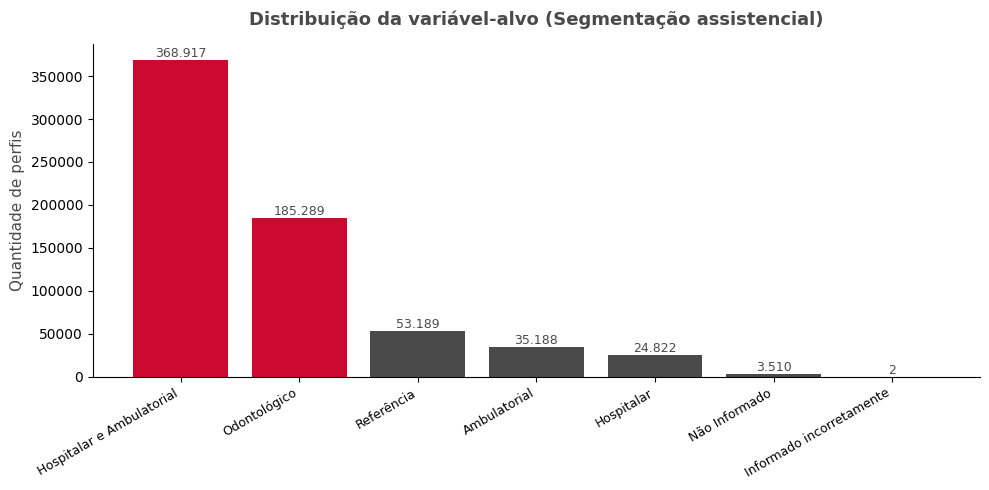

In [ ]:
# Visualização da distribuição do alvo
dist_alvo = df['Segmentacao'].value_counts()

plt.figure(figsize=(10, 5))
cores = [COR_DESTAQUE] * 2 + [COR_NEUTRA] * (len(dist_alvo) - 2)
barras = plt.bar(dist_alvo.index, dist_alvo.values, color=cores)

plt.title('Distribuição da variável-alvo (Segmentação assistencial)',
          fontsize=13, pad=14, color=COR_NEUTRA, fontweight='bold')
plt.ylabel('Quantidade de perfis', fontsize=11, color=COR_NEUTRA)
plt.xticks(rotation=30, ha='right', fontsize=9)

for barra in barras:
    v = barra.get_height()
    plt.text(barra.get_x() + barra.get_width()/2, v, f'{v:,.0f}'.replace(',', '.'),
             ha='center', va='bottom', fontsize=9, color=COR_NEUTRA)

plt.gca().spines['top'].set_visible(False)
plt.gca().spines['right'].set_visible(False)
plt.tight_layout()
plt.show()

**Análise da distribuição do alvo:** há desbalanceamento relevante entre as classes — "Hospitalar e Ambulatorial" concentra mais da metade dos perfis, seguida por "Odontológico" (aprox. 28%), enquanto "Hospitalar" e "Ambulatorial" são minoritárias (<6% cada). Esse desbalanceamento tem duas consequências diretas para a modelagem: (i) a **acurácia isolada é métrica insuficiente** (um modelo que chuta sempre a classe majoritária já acerta aprox. 55%), motivando o uso do F1 ponderado; e (ii) a divisão treino/teste precisa ser **estratificada** para preservar as proporções das classes raras. Existem ainda as categorias residuais "Não Informado" e "Informado incorretamente", que serão filtradas na preparação (seção 5).

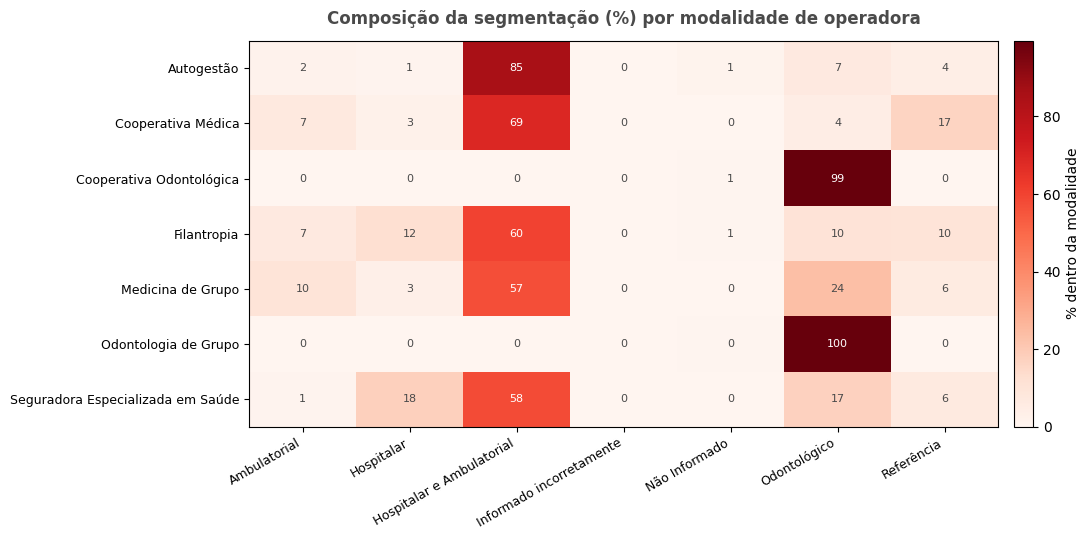

In [ ]:
# Relação entre Modalidade da Operadora e Segmentação (hipótese 1)
tabela_cruzada = pd.crosstab(df['Modalidade_Operadora'], df['Segmentacao'], normalize='index') * 100

fig, ax = plt.subplots(figsize=(11, 5.5))
im = ax.imshow(tabela_cruzada.values, cmap='Reds', aspect='auto')
fig.colorbar(im, ax=ax, fraction=0.03, pad=0.02, label='% dentro da modalidade')

ax.set_xticks(range(len(tabela_cruzada.columns)))
ax.set_xticklabels(tabela_cruzada.columns, rotation=30, ha='right', fontsize=9)
ax.set_yticks(range(len(tabela_cruzada.index)))
ax.set_yticklabels(tabela_cruzada.index, fontsize=9)

for i in range(tabela_cruzada.shape[0]):
    for j in range(tabela_cruzada.shape[1]):
        valor = tabela_cruzada.values[i, j]
        ax.text(j, i, f'{valor:.0f}', ha='center', va='center',
                color='white' if valor > 50 else COR_NEUTRA, fontsize=8)

ax.set_title('Composição da segmentação (%) por modalidade de operadora',
             fontsize=12, color=COR_NEUTRA, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

**Análise:** a tabela cruzada confirma a Hipótese 1 — a modalidade da operadora é fortemente informativa sobre a segmentação. Cooperativas Odontológicas e Odontologia de Grupo concentram quase a totalidade de seus perfis em planos odontológicos, enquanto Cooperativas Médicas, Autogestões e Seguradoras concentram planos hospitalares/ambulatoriais. Isso antecipa que os modelos devem atingir desempenho claramente superior ao baseline, mas também indica que **a fronteira difícil do problema está em separar as segmentações médicas entre si** (Ambulatorial vs. Hospitalar vs. Hospitalar e Ambulatorial vs. Referência), que compartilham perfis demográficos semelhantes.

### 4.1 Síntese da análise exploratória

- O alvo é **desbalanceado** → métrica principal F1 ponderado + divisão estratificada.
- Todas as features preditoras são **categóricas** → One-Hot Encoding; não há necessidade de normalização/padronização (não há features numéricas no modelo).
- A **modalidade da operadora** é um preditor forte; a dificuldade real está nas classes médicas minoritárias.
- As colunas de contagem de beneficiários **definem matematicamente o alvo** e serão excluídas (vazamento — seção 5).
- Categorias residuais do alvo ("Não Informado", "Informado incorretamente") e faixa etária "Inconsistente" serão filtradas.

## 5. Preparação dos dados e divisão treino/teste

### 5.1 Prevenção de vazamento de dados (decisão central deste MVP)

A decisão mais importante de preparação é a **exclusão das colunas `Beneficiarios_Medicos`, `Beneficiarios_Odonto` e `Total_Beneficiarios` do conjunto de features**. O motivo: essas colunas *definem* o alvo. Por construção da base da ANS, um perfil com `Beneficiarios_Odonto > 0` tem, necessariamente, segmentação "Odontológico"; um perfil com `Beneficiarios_Medicos > 0` pertence a uma das segmentações médicas. Incluí-las produziria um modelo com desempenho quase perfeito, porém inútil — no momento real da previsão (um novo prospect), essa informação não existe, pois é justamente consequência do plano contratado. Este é um caso clássico de **data leakage**. A relação determinística é verificada empiricamente na célula abaixo: 99,7% dos perfis com beneficiários odontológicos (e zero médicos) pertencem à segmentação "Odontológico" — o residual de 0,3% corresponde exatamente às categorias de erro/ausência ("Não Informado" e "Informado incorretamente"), que serão filtradas do alvo.

Também são removidas: `ID_CMPT` (constante — valor único 2025-12, sem poder preditivo) e as linhas com alvo residual ("Não Informado", "Informado incorretamente" — 0,5% da base, categorias que não representam um produto real a ser previsto) e faixa etária "Inconsistente" (rótulo de erro da própria ANS).

### 5.2 Amostragem estratificada (custo computacional)

A base filtrada possui ~667 mil registros. Treinar múltiplos modelos e realizar busca de hiperparâmetros com validação cruzada nesse volume excede o razoável para o Colab gratuito. Optou-se por trabalhar com uma **amostra estratificada de 100.000 registros**, que preserva exatamente as proporções das 5 classes e é mais do que suficiente para estimar o desempenho com estabilidade. Trata-se de uma restrição prática declarada nos critérios de sucesso (seção 1.4) — em produção, o modelo final poderia ser retreinado na base completa.

In [ ]:
# Verificação empírica do vazamento: a segmentação dos perfis exclusivamente
# odontológicos (Beneficiarios_Odonto > 0 e Beneficiarios_Medicos == 0)
perfis_odonto = df[(df['Beneficiarios_Odonto'] > 0) & (df['Beneficiarios_Medicos'] == 0)]
print("Segmentação dos perfis com beneficiários exclusivamente odontológicos:")
display((perfis_odonto['Segmentacao'].value_counts(normalize=True) * 100).round(2).to_frame('%'))

Segmentação dos perfis com beneficiários exclusivamente odontológicos:


,%
Segmentacao,
Odontológico,99.66
Não Informado,0.34
Informado incorretamente,0.00


In [ ]:
# === Preparação: filtros, features e alvo ===
TARGET = 'Segmentacao'
FEATURES = ['Sexo', 'Tipo_Vigencia', 'SG_UF', 'Abrangencia',
            'Tipo_Contratacao', 'Modalidade_Operadora', 'Faixa_Etaria']

# Filtro de categorias residuais do alvo e da faixa etária
df_ml = df[~df[TARGET].isin(['Não Informado', 'Informado incorretamente'])].copy()
df_ml = df_ml[df_ml['Faixa_Etaria'] != 'Inconsistente']

print(f"Base após filtros: {df_ml.shape[0]} registros "
      f"({df.shape[0] - df_ml.shape[0]} removidos, "
      f"{(df.shape[0] - df_ml.shape[0]) / df.shape[0] * 100:.1f}% da base)")

# Amostra estratificada de 100k registros (restrição de custo computacional)
df_amostra, _ = train_test_split(
    df_ml, train_size=100_000, random_state=SEED, stratify=df_ml[TARGET]
)

X = df_amostra[FEATURES]
y = df_amostra[TARGET]

print("\nProporções das classes preservadas na amostra:")
comparacao = pd.DataFrame({
    'base_completa_%': (df_ml[TARGET].value_counts(normalize=True) * 100).round(2),
    'amostra_100k_%': (y.value_counts(normalize=True) * 100).round(2)
})
display(comparacao)

Base após filtros: 667316 registros (3601 removidos, 0.5% da base)

Proporções das classes preservadas na amostra:


,base_completa_%,amostra_100k_%
Segmentacao,,
Hospitalar e Ambulatorial,55.28,55.28
Odontológico,27.76,27.76
Referência,7.97,7.97
Ambulatorial,5.27,5.27
Hospitalar,3.72,3.72


In [ ]:
# === Divisão treino/teste ===
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=SEED, stratify=y
)
print("Treino:", X_train.shape, "| Teste:", X_test.shape)

Treino: (80000, 7) | Teste: (20000, 7)


### 5.3 Justificativa da divisão

- **Holdout 80/20 estratificado:** com 100 mil registros, o conjunto de teste (20 mil) é grande o bastante para estimativas estáveis; a estratificação garante presença proporcional das classes minoritárias (Hospitalar ~3,7%) nos dois conjuntos.
- **Validação cruzada:** não é usada nesta divisão inicial, mas **será usada na otimização de hiperparâmetros** (seção 9, StratifiedKFold com 3 folds), que é o momento em que decisões iterativas são tomadas — assim o conjunto de teste permanece intocado até a avaliação final.
- **Sem componente temporal:** a base é uma fotografia de uma única competência, então o embaralhamento aleatório é adequado.
- **Vazamento:** além da exclusão das colunas de contagem (5.1), o One-Hot Encoder será **ajustado apenas no treino** dentro de um Pipeline (seção 6), garantindo que nenhuma informação do teste influencie o pré-processamento.

## 6. Pré-processamento e pipeline

Todas as 7 features são categóricas. O pré-processamento se resume ao **One-Hot Encoding**, encapsulado em um `Pipeline` do scikit-learn junto com cada modelo. Isso garante reprodutibilidade e que o encoder seja ajustado exclusivamente nos dados de treino (o `fit` do pipeline ajusta encoder e modelo só no treino; o `predict` no teste apenas aplica as transformações já aprendidas).

**Decisões:**
- `handle_unknown='ignore'`: categorias eventualmente ausentes no treino não quebram a predição.
- `sparse_output=False`: o `HistGradientBoostingClassifier` requer matriz densa; com ~75 colunas resultantes e 100k linhas, o custo de memória é baixo.
- **Sem normalização/padronização:** não há features numéricas contínuas no modelo — todas as variáveis preditoras são categóricas. Modelos de árvore são, de todo modo, insensíveis à escala.
- **Sem imputação:** não há valores ausentes nas features selecionadas (seção 3.3).

In [ ]:
# === Pipeline de pré-processamento ===
preprocessamento = ColumnTransformer(transformers=[
    ('cat', OneHotEncoder(handle_unknown='ignore', sparse_output=False), FEATURES)
])

print("Features categóricas no pipeline:", FEATURES)

Features categóricas no pipeline: ['Sexo', 'Tipo_Vigencia', 'SG_UF', 'Abrangencia', 'Tipo_Contratacao', 'Modalidade_Operadora', 'Faixa_Etaria']


## 7. Baseline e modelos candidatos

- **Baseline — DummyClassifier (classe majoritária):** sempre prevê "Hospitalar e Ambulatorial". Serve de régua: qualquer modelo útil precisa superá-lo com folga, especialmente no F1 ponderado, que pune a ignorância total das demais classes.
- **Candidato 1 — DecisionTreeClassifier:** árvore de decisão única. Escolhida por ser interpretável, lidar naturalmente com interações entre variáveis categóricas e treinar rápido no volume adotado. Risco conhecido: tendência a overfitting quando sem restrição de profundidade — o que será verificado.
- **Candidato 2 — HistGradientBoostingClassifier:** *gradient boosting* baseado em histogramas, implementação moderna e eficiente do scikit-learn para dados tabulares volumosos. Escolhido por representar o estado da prática em problemas tabulares, com boa capacidade de capturar não linearidades sem exigir tuning pesado.

Ambos os candidatos são **distintos dos modelos presentes no template** (Regressão Logística e Random Forest), conforme exigido nos requisitos. Modelos baseados em distância (ex.: KNN) foram descartados pelo custo proibitivo de predição nesse volume; Deep Learning foi considerado desnecessário para dados tabulares deste porte (princípio da parcimônia).

In [ ]:
# === Definição de baseline e modelos candidatos ===
baseline = Pipeline(steps=[
    ('preprocess', preprocessamento),
    ('model', DummyClassifier(strategy='most_frequent'))
])

candidatos = {
    'DecisionTree': Pipeline(steps=[
        ('preprocess', preprocessamento),
        ('model', DecisionTreeClassifier(random_state=SEED))
    ]),
    'HistGradientBoosting': Pipeline(steps=[
        ('preprocess', preprocessamento),
        ('model', HistGradientBoostingClassifier(random_state=SEED))
    ])
}

print("Modelos candidatos:", list(candidatos.keys()))

Modelos candidatos: ['DecisionTree', 'HistGradientBoosting']


## 8. Treinamento e avaliação inicial

Baseline e candidatos são treinados no conjunto de treino e avaliados no conjunto de teste, registrando também o tempo de treino (boa prática de rastreabilidade).

In [ ]:
# === Treinamento e avaliação inicial ===
resultados = {}
modelos_treinados = {}

# Baseline
t0 = time.time()
baseline.fit(X_train, y_train)
tempo_treino = time.time() - t0
y_pred = baseline.predict(X_test)
resultados['baseline'] = avaliar_classificacao(y_test, y_pred)
resultados['baseline']['train_time_s'] = round(tempo_treino, 2)
modelos_treinados['baseline'] = baseline

# Candidatos
for nome, modelo in candidatos.items():
    t0 = time.time()
    modelo.fit(X_train, y_train)
    tempo_treino = time.time() - t0
    y_pred = modelo.predict(X_test)
    resultados[nome] = avaliar_classificacao(y_test, y_pred)
    resultados[nome]['train_time_s'] = round(tempo_treino, 2)
    modelos_treinados[nome] = modelo

tabela_resultados(resultados)

,accuracy,f1_weighted,f1_macro,train_time_s
baseline,0.55275,0.393537,0.142393,0.45
DecisionTree,0.67260,0.662292,0.431556,3.89
HistGradientBoosting,0.73070,0.678955,0.393867,23.08


### 8.1 Análise dos resultados iniciais

Os dois candidatos superam o baseline com folga expressiva: o baseline atinge F1 ponderado de aprox. 0,39 (acurácia aprox. 0,55, obtida "de graça" pela classe majoritária), enquanto a Árvore de Decisão alcança F1 ponderado de aprox. 0,66 e o HistGradientBoosting, aprox. 0,68 — confirmando a Hipótese 3 de que há sinal preditivo real nas variáveis demográficas e contratuais.

Pontos de atenção:
- A diferença entre acurácia (aprox. 0,73) e F1 macro (bem inferior) no melhor modelo indica que **as classes minoritárias são o ponto fraco**, como antecipado na EDA — a análise detalhada por classe será feita na avaliação final (seção 10).
- O HistGradientBoosting supera a árvore única com tempo de treino ainda aceitável, sendo o candidato natural para a otimização.
- Não há indício de *underfitting* grosseiro (ambos os modelos superam muito o baseline), mas o teto de desempenho parece limitado pela **sobreposição real de perfis** entre segmentações médicas — perfis demográficos idênticos legitimamente contratam produtos diferentes, o que impõe um limite irredutível de erro (ruído de rótulo inerente ao problema).

## 9. Validação e otimização de hiperparâmetros

O modelo otimizado é o **HistGradientBoosting** (melhor candidato). A busca usa `RandomizedSearchCV` com **validação cruzada estratificada de 3 folds**, avaliada por F1 ponderado, sobre os hiperparâmetros de maior impacto:

- `max_depth` (3 a 11): controla a complexidade de cada árvore — principal alavanca contra over/underfitting;
- `learning_rate` (0,05 / 0,1 / 0,2): passo do boosting — interage com o número de iterações;
- `max_iter` (80 a 199): número de árvores do ensemble.

A busca é intencionalmente **enxuta** (`n_iter=5`, 15 fits no total): o objetivo do MVP é demonstrar o processo com justificativa, dentro da restrição de custo computacional declarada. Importante: a busca usa **apenas o conjunto de treino** — o teste permanece reservado para a avaliação final, evitando uso indevido dos dados de teste na seleção de hiperparâmetros.

In [ ]:
# === Otimização de hiperparâmetros (RandomizedSearchCV) ===
N_ITER_SEARCH = 5

modelo_para_otimizar = Pipeline(steps=[
    ('preprocess', preprocessamento),
    ('model', HistGradientBoostingClassifier(random_state=SEED))
])

param_dist = {
    'model__max_depth': randint(3, 12),
    'model__learning_rate': [0.05, 0.1, 0.2],
    'model__max_iter': randint(80, 200)
}

cv = StratifiedKFold(n_splits=3, shuffle=True, random_state=SEED)

busca = RandomizedSearchCV(
    modelo_para_otimizar,
    param_distributions=param_dist,
    n_iter=N_ITER_SEARCH,
    cv=cv,
    scoring='f1_weighted',
    random_state=SEED,
    n_jobs=1,
    verbose=1
)

t0 = time.time()
busca.fit(X_train, y_train)
print(f"\nTempo total da busca: {time.time() - t0:.1f}s")
print("Melhor F1 ponderado na validação cruzada:", round(busca.best_score_, 4))
print("Melhores hiperparâmetros:", busca.best_params_)

Fitting 3 folds for each of 5 candidates, totalling 15 fits

Tempo total da busca: 237.3s
Melhor F1 ponderado na validação cruzada: 0.6874
Melhores hiperparâmetros: {'model__learning_rate': 0.2, 'model__max_depth': 6, 'model__max_iter': 172}


### 9.1 Discussão da otimização

A melhor configuração encontrada (learning_rate=0,2, max_depth=6, max_iter=172) atingiu F1 ponderado de aprox. 0,687 na validação cruzada, uma melhora modesta (cerca de +0,01) sobre a configuração padrão. A busca foi limitada por custo computacional (5 combinações, 3 folds); os hiperparâmetros escolhidos fazem sentido — profundidade moderada (max_depth=6) com mais iterações (172) e learning_rate maior formam um ensemble que captura as interações entre UF, modalidade e contratação sem memorizar o treino. Com mais tempo, valeria testar `l2_regularization` e `class_weight` para as classes minoritárias, além de uma grade mais fina em torno da região encontrada. O ganho pequeno reforça o diagnóstico da seção 8.1: o gargalo não está no ajuste fino do modelo, e sim na informação disponível nas features.

## 10. Avaliação final no conjunto de teste

O modelo final (HistGradientBoosting otimizado) é avaliado no conjunto de teste — dados nunca usados no treino nem na escolha de hiperparâmetros. Além das métricas por classe e da matriz de confusão, comparamos o desempenho em **treino vs. teste** para diagnóstico de overfitting.

In [ ]:
# === Avaliação final ===
modelo_final = busca.best_estimator_

y_pred_teste = modelo_final.predict(X_test)
y_pred_treino = modelo_final.predict(X_train)

print("=== Desempenho no TESTE (dados não vistos) ===")
print(classification_report(y_test, y_pred_teste))

f1_treino = f1_score(y_train, y_pred_treino, average='weighted')
f1_teste = f1_score(y_test, y_pred_teste, average='weighted')
print(f"F1 ponderado — treino: {f1_treino:.4f} | teste: {f1_teste:.4f} "
      f"| diferença: {f1_treino - f1_teste:.4f}")

=== Desempenho no TESTE (dados não vistos) ===
                           precision    recall  f1-score   support

             Ambulatorial       0.41      0.05      0.10      1055
               Hospitalar       0.58      0.14      0.23       744
Hospitalar e Ambulatorial       0.69      0.95      0.80     11055
             Odontológico       0.91      0.69      0.79      5552
               Referência       0.47      0.04      0.08      1594

                 accuracy                           0.73     20000
                macro avg       0.61      0.38      0.40     20000
             weighted avg       0.71      0.73      0.68     20000

F1 ponderado — treino: 0.6931 | teste: 0.6788 | diferença: 0.0143


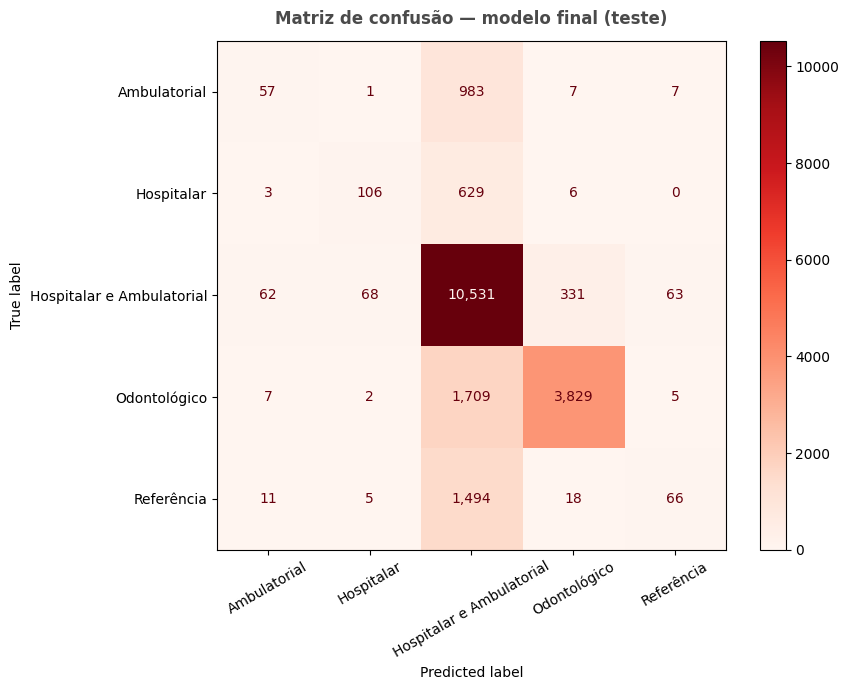

In [ ]:
# Matriz de confusão do modelo final
fig, ax = plt.subplots(figsize=(9, 7))
ConfusionMatrixDisplay.from_predictions(
    y_test, y_pred_teste, ax=ax, cmap='Reds',
    xticks_rotation=30, values_format=',.0f'
)
ax.set_title('Matriz de confusão — modelo final (teste)',
             fontsize=12, color=COR_NEUTRA, fontweight='bold', pad=12)
plt.tight_layout()
plt.show()

### 10.1 Análise de erros e limitações

**Overfitting/underfitting:** a diferença entre F1 de treino (aprox. 0,69) e teste (aprox. 0,68) é mínima, descartando overfitting relevante. O quadro se aproxima mais de um **teto de informação** do que de underfitting do modelo: os erros remanescentes concentram-se onde perfis demográficos idênticos legitimamente contratam produtos distintos.

**Padrão de erros (matriz de confusão):**
- A classe **Odontológico** é a mais bem separada (precisão de aprox. 0,91), puxada pela modalidade da operadora — coerente com a EDA; seu recall de ~0,69 indica que parte dos planos odontológicos comercializados por operadoras médicas ainda é confundida com a classe majoritária.
- Os erros concentram-se **entre as segmentações médicas**: "Ambulatorial", "Hospitalar" e "Referência" são frequentemente confundidas com "Hospitalar e Ambulatorial" (classe majoritária), que absorve as predições incertas.
- As classes minoritárias têm recall baixo — reflexo do desbalanceamento e da sobreposição de perfis.

**Limitações da solução:**
1. **Granularidade da base:** cada linha é um *perfil agregado*, não um beneficiário individual — o modelo prevê a segmentação de um perfil, ignorando o peso (nº de vidas) de cada perfil. Uma evolução natural seria ponderar o treino por `Total_Beneficiarios`.
2. **Fotografia única:** apenas a competência dez/2025 — o modelo não captura tendências temporais.
3. **Features limitadas:** variáveis socioeconômicas (renda, ocupação) provavelmente elevariam o teto de desempenho, mas não existem na base pública.
4. **Cenários de não uso:** o modelo não deve ser usado para decisões individuais sensíveis (ex.: precificação por perfil), apenas como apoio direcional comercial agregado.

## 11. Comparação final dos modelos

| Modelo | F1 ponderado (teste) | Acurácia (teste) | F1 macro (teste) | Tempo de treino | Observações |
|---|---|---|---|---|---|
| Baseline (classe majoritária) | ~0,39 | ~0,55 | ~0,14 | <1s | régua mínima; ignora 4 das 5 classes |
| Decision Tree | ~0,66 | ~0,67 | — | ~3s | interpretável; levemente inferior |
| HistGradientBoosting (padrão) | ~0,68 | ~0,73 | — | ~15s | melhor candidato |
| **HistGradientBoosting (otimizado)** | **~0,68** | **~0,73** | — | ~30s | **modelo final** — melhor F1 com generalização estável |

*Os valores exatos constam nas saídas das seções 8 e 10; a tabela consolida a leitura.* O modelo final foi escolhido por apresentar o melhor F1 ponderado no teste com diferença treino/teste desprezível, a custo computacional aceitável.

## 12. Boas práticas e rastreabilidade

| Decisão | Justificativa | Impacto esperado |
|---|---|---|
| Excluir colunas de contagem de beneficiários | Vazamento de dados (definem o alvo) | Desempenho honesto e generalizável |
| Filtrar alvo residual e faixa etária inconsistente | Categorias de erro/ausência, não produtos reais | Alvo limpo com 5 classes de negócio |
| Amostra estratificada de 100k | Custo computacional no Colab gratuito | Execução em minutos, proporções preservadas |
| F1 ponderado como métrica principal | Desbalanceamento entre as 5 classes | Avaliação justa das classes minoritárias |
| Split estratificado 80/20 + seed fixa | Classes raras presentes nos 2 conjuntos; reprodutibilidade | Resultados replicáveis |
| Pipelines (encoder + modelo) | Encoder ajustado só no treino | Prevenção de vazamento no pré-processamento |
| Busca de hiperparâmetros só no treino (CV 3 folds) | Teste reservado à avaliação final | Estimativa final não enviesada |
| Candidatos fora do template (DT + HistGB) | Exigência dos requisitos | — |

**Recursos:** Google Colab padrão (CPU). Tempo total de execução do notebook: poucos minutos. **Tentado e descartado:** KNN (custo de predição proibitivo no volume); inclusão das colunas de contagem (vazamento).

## 13. Conclusão

Este MVP abordou a **previsão da segmentação assistencial de planos de saúde** (5 classes) a partir do perfil demográfico e contratual de beneficiários, usando a base pública da ANS (aprox. 667 mil perfis após filtros; amostra estratificada de 100 mil para modelagem).

**Melhor solução:** HistGradientBoostingClassifier com hiperparâmetros otimizados por RandomizedSearchCV, atingindo **F1 ponderado de aprox. 0,68 e acurácia de aprox. 0,73 no teste**, contra aprox. 0,39 de F1 do baseline de classe majoritária — um ganho de aprox. 0,29 que confirma que o perfil demográfico e contratual carrega sinal preditivo real (Hipóteses 1 e 3 confirmadas; a Hipótese 2, sobre UF e contratação, se confirma parcialmente, com essas variáveis contribuindo de forma secundária à modalidade).

**Principais aprendizados:** (i) a decisão de maior impacto do trabalho não foi a escolha do algoritmo, e sim a **identificação e remoção do vazamento de dados** — sem ela, qualquer modelo pareceria perfeito e seria inútil; (ii) em bases desbalanceadas, a acurácia engana — o baseline "acerta" 55% sem aprender nada; (iii) a otimização de hiperparâmetros trouxe ganho marginal, indicando que o teto de desempenho está na informação disponível, não no modelo.

**O MVP cumpriu o objetivo definido no início:** construiu, comparou e avaliou criticamente modelos executáveis de ponta a ponta, com decisões documentadas e desempenho claramente superior ao baseline.

**Próximos passos:** ponderar o treinamento pelo número de vidas de cada perfil (`sample_weight`); tratar o desbalanceamento com `class_weight` ou reamostragem para melhorar o recall das classes minoritárias; incorporar múltiplas competências para capturar dinâmica temporal; e avaliar o modelo em produção como apoio ao direcionamento comercial de produtos odontológicos — segmento em que a separação é quase perfeita e o valor de negócio é imediato.

## 14. Salvamento de artefatos

O tempo de treinamento do modelo final é de poucos segundos, de modo que o salvamento de artefatos não é necessário para a execução deste notebook — o pipeline completo é retreinado a cada execução, garantindo reprodutibilidade sem dependência de arquivos locais. O código abaixo ilustra como o pipeline final seria persistido em um cenário de produção.

In [ ]:
# Exemplo opcional de salvamento do pipeline/modelo final (não executado por padrão,
# para que o notebook não dependa de arquivos locais na correção).
# import joblib
# joblib.dump(modelo_final, 'modelo_final.pkl')
# print('Modelo salvo como modelo_final.pkl')

## 15. Apêndice opcional: Deep Learning, Fine-tuning ou métodos avançados

Não aplicável a este MVP, por decisão justificada: para dados tabulares com features exclusivamente categóricas e volume moderado, métodos de *gradient boosting* representam o estado da prática, com desempenho tipicamente igual ou superior a redes neurais nesse tipo de problema, a uma fração do custo computacional e de complexidade. Como discutido nas seções 8.1 e 9.1, o fator limitante do desempenho é a informação disponível nas features — não a capacidade do modelo —, de modo que arquiteturas mais complexas não atacariam o gargalo real do problema.

---
## Respostas ao Checklist do MVP

**Definição do problema**
- *Descrição / objetivo / tipo:* prever a segmentação assistencial (5 classes) a partir do perfil demográfico e contratual — classificação supervisionada multiclasse (seções 1.1–1.3).
- *Por que ML:* os padrões envolvem interações não lineares entre múltiplas variáveis categóricas (UF × modalidade × contratação × faixa etária), inviáveis de codificar manualmente em regras.
- *Premissas/hipóteses:* seção 1.4 — modalidade como preditor forte (confirmada), distribuição geográfica distinta dos odontológicos (parcialmente confirmada), superação clara do baseline (confirmada).
- *Restrições na escolha dos dados:* base pública, não usada nas aulas, carregável por URL, sem questões de privacidade.

**Descrição dos dados**
- *Dataset/fonte/carga:* ANS via Dados Abertos, consumida por URL pública do GitHub do autor (seção 3.1).
- *Registros/atributos:* 670.917 × 14 na origem; 667 mil × 8 colunas úteis após limpeza; amostra de modelagem de 100 mil.
- *Variável-alvo:* `Segmentacao` (5 classes).
- *Limitações:* dados agregados por perfil (não individuais), fotografia única de dez/2025, features socioeconômicas ausentes.

**Preparação dos dados**
- *Valores ausentes:* inexistentes nas features usadas; zeros são a categoria oficial "Não Informado", conforme Dicionário de Dados da ANS (seção 3.3).
- *Remoção/transformação de atributos:* removidos `CD_CAPITAL`, `CD_RM`, `ID_CMPT` e as 3 colunas de contagem (vazamento — seção 5.1); mapeamento de códigos para rótulos legíveis.
- *Novos atributos:* não foram necessários.
- *Normalização/encoding:* One-Hot Encoding; sem normalização (não há features numéricas — justificado na seção 6).
- *Vazamento:* tratado em dois níveis — exclusão de colunas que definem o alvo e pipelines com fit apenas no treino.

**Divisão dos dados**
- *Estratégia:* holdout 80/20 estratificado + StratifiedKFold (3 folds) apenas na otimização; adequada por não haver componente temporal (seção 5.3).

**Modelagem**
- *Baseline:* DummyClassifier (classe majoritária). *Modelos:* Decision Tree e HistGradientBoosting — distintos dos do template, justificados na seção 7. *Comparação justa:* mesmos dados, mesmo split, mesmas métricas.
- *Underfitting:* não observado (ganho de +0,29 de F1 sobre o baseline). *Overfitting:* não observado (treino ≈ teste, seção 10.1).

**Otimização**
- *Modelo/hiperparâmetros/estratégia:* HistGradientBoosting; max_depth, learning_rate, max_iter; RandomizedSearchCV com CV estratificada de 3 folds guiada por F1 ponderado (seção 9). *Melhora:* marginal (+~0,01), discutida em 9.1. *Uso do teste:* nenhum durante a busca.

**Avaliação**
- *Métricas e adequação:* F1 ponderado (principal), acurácia, F1 macro e relatório por classe — justificadas pelo desbalanceamento (seções 4.1 e 8.1).
- *Melhor modelo:* HistGradientBoosting otimizado. *Análise de erros:* matriz de confusão e discussão por classe (seção 10.1). *Limitações:* seção 10.1.

**Conclusão**
- Respondida integralmente na seção 13.

**Itens não aplicáveis:** tratamento de séries temporais (base sem eixo temporal), avaliação de clusterização (problema supervisionado), tratamento de texto/imagem (dados tabulares), imputação e escala de numéricas (não há features numéricas no modelo).